In [1]:
%matplotlib inline
import os
import warnings 
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn import preprocessing
from mord import OrdinalRidge
from sklearn.linear_model import LinearRegression
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error,accuracy_score,mean_absolute_error,r2_score
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report


In [2]:
# Load the data
base = "./wine+quality"

wine_red_df = pd.read_csv(os.path.join(base,"winequality-red.csv"), sep = ";")
wine_white_df = pd.read_csv(os.path.join(base,"winequality-white.csv"), sep = ";")

In [23]:
display(wine_white_df.head())

display(wine_red_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [24]:
wine_white_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [25]:
wine_red_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [26]:
np.round(wine_white_df.describe(),3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000
mean,6.855,0.278,0.334,6.391,0.046,35.308,138.361,0.994,3.188,0.490,10.514,5.878
std,0.844,0.101,0.121,5.072,0.022,17.007,42.498,0.003,0.151,0.114,1.231,0.886
min,3.800,0.080,0.000,0.600,0.009,2.000,9.000,0.987,2.720,0.220,8.000,3.000
25%,6.300,0.210,0.270,1.700,0.036,23.000,108.000,0.992,3.090,0.410,9.500,5.000
50%,6.800,0.260,0.320,5.200,0.043,34.000,134.000,0.994,3.180,0.470,10.400,6.000
75%,7.300,0.320,0.390,9.900,0.050,46.000,167.000,0.996,3.280,0.550,11.400,6.000
max,14.200,1.100,1.660,65.800,0.346,289.000,440.000,1.039,3.820,1.080,14.200,9.000


In [27]:
np.round(wine_red_df.describe(),3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


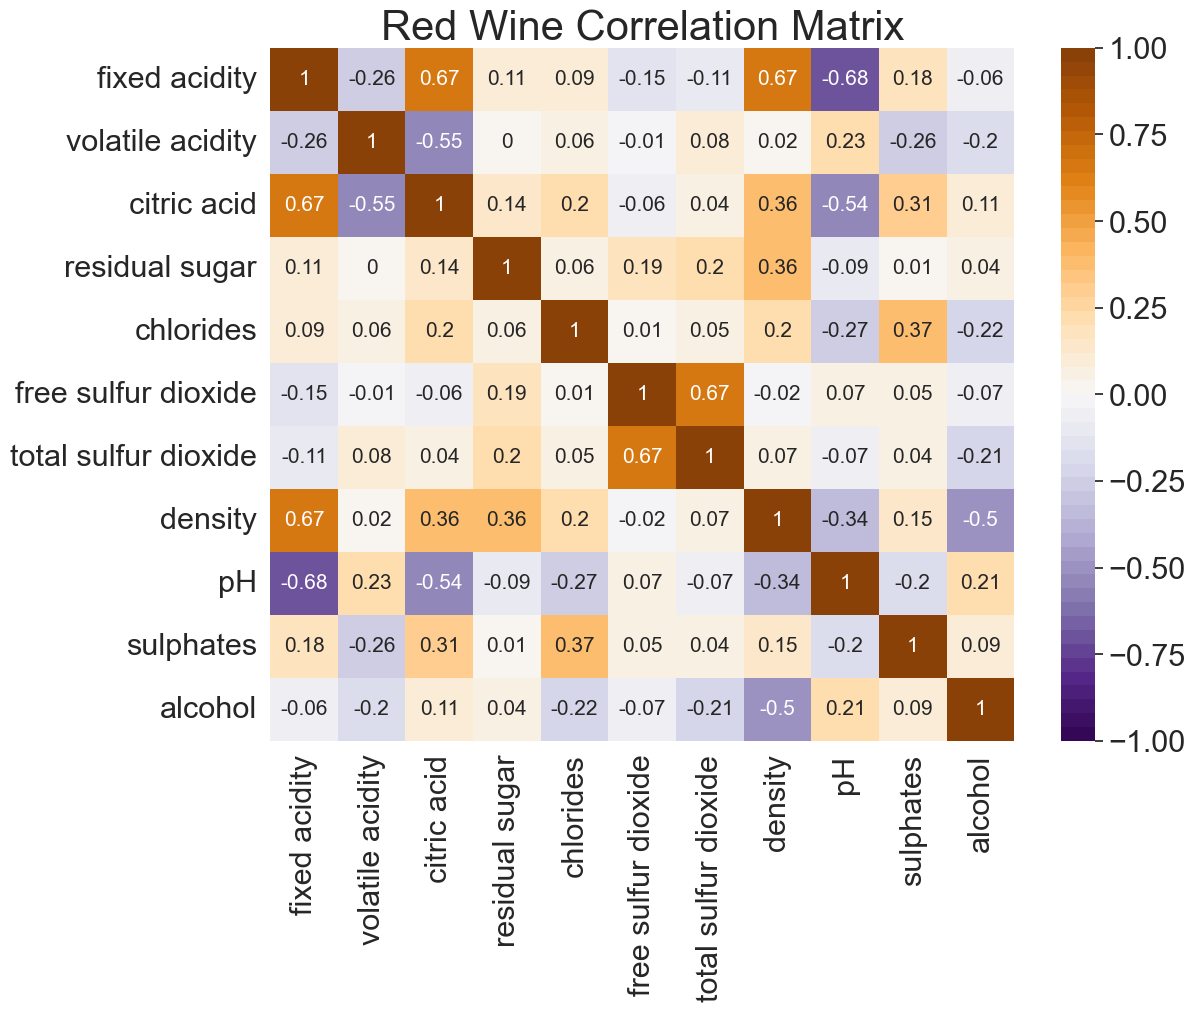

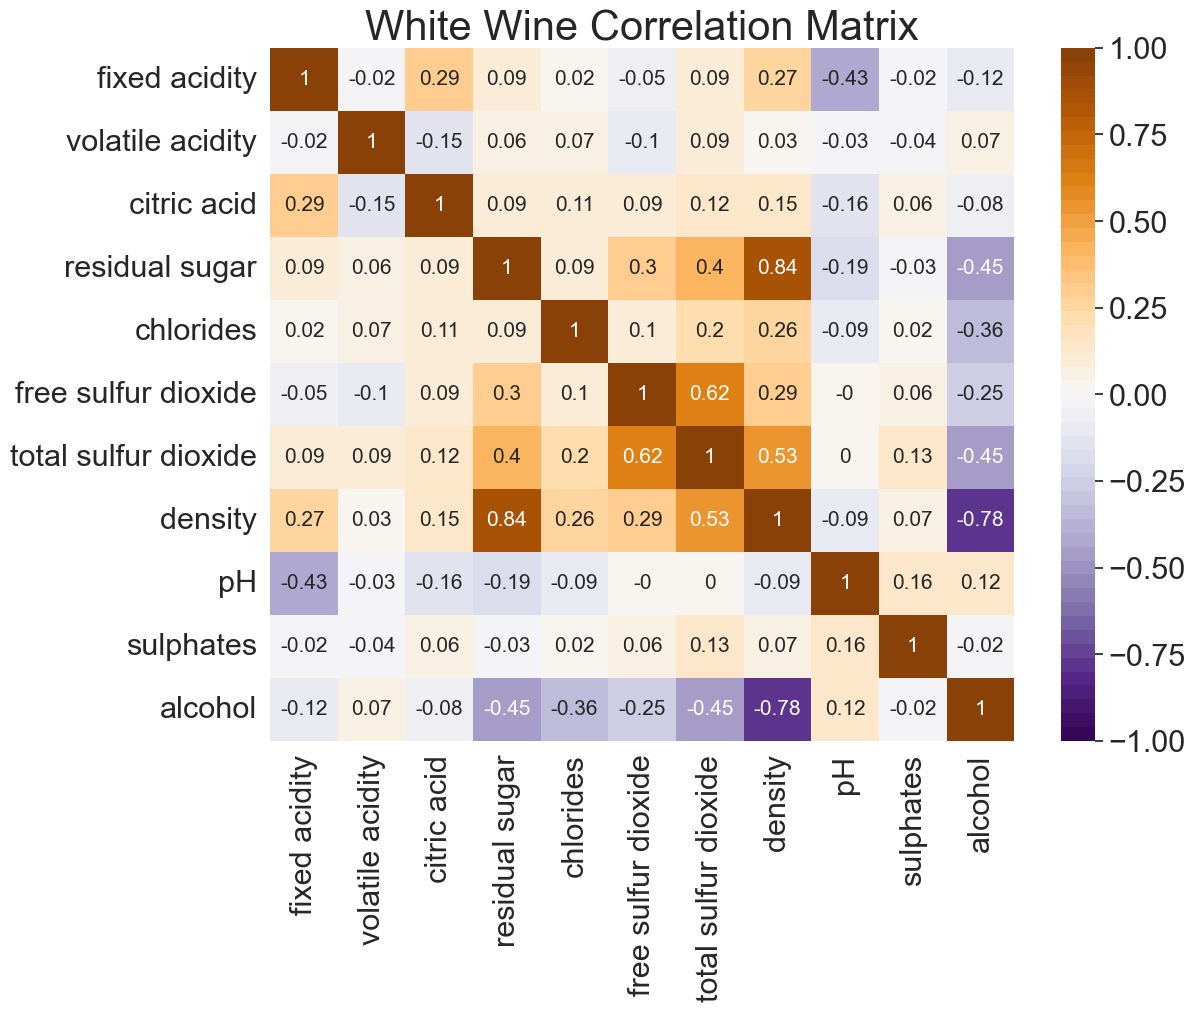

In [30]:


def coorelation_matrix_plot(data, title = "Wine Correlation Matrix", height = 9, width = 12):
    cor_mat = round(data.corr(method ="pearson"), 2)
    plt.figure(figsize = (width, height))
    ax = sns.heatmap(cor_mat, annot=True, annot_kws={"size": 15}, cmap = sns.color_palette("PuOr_r", 50), 
                     vmin = -1, vmax = 1)
    ax.axes.set_title(title, fontsize = 30)
    ax.title.set_position([.5, 1.03])
    plt.show()
    
coorelation_matrix_plot(wine_red_df.iloc[:,:-1], title = "Red Wine Correlation Matrix")

coorelation_matrix_plot(wine_white_df.iloc[:,:-1], title = "White Wine Correlation Matrix")

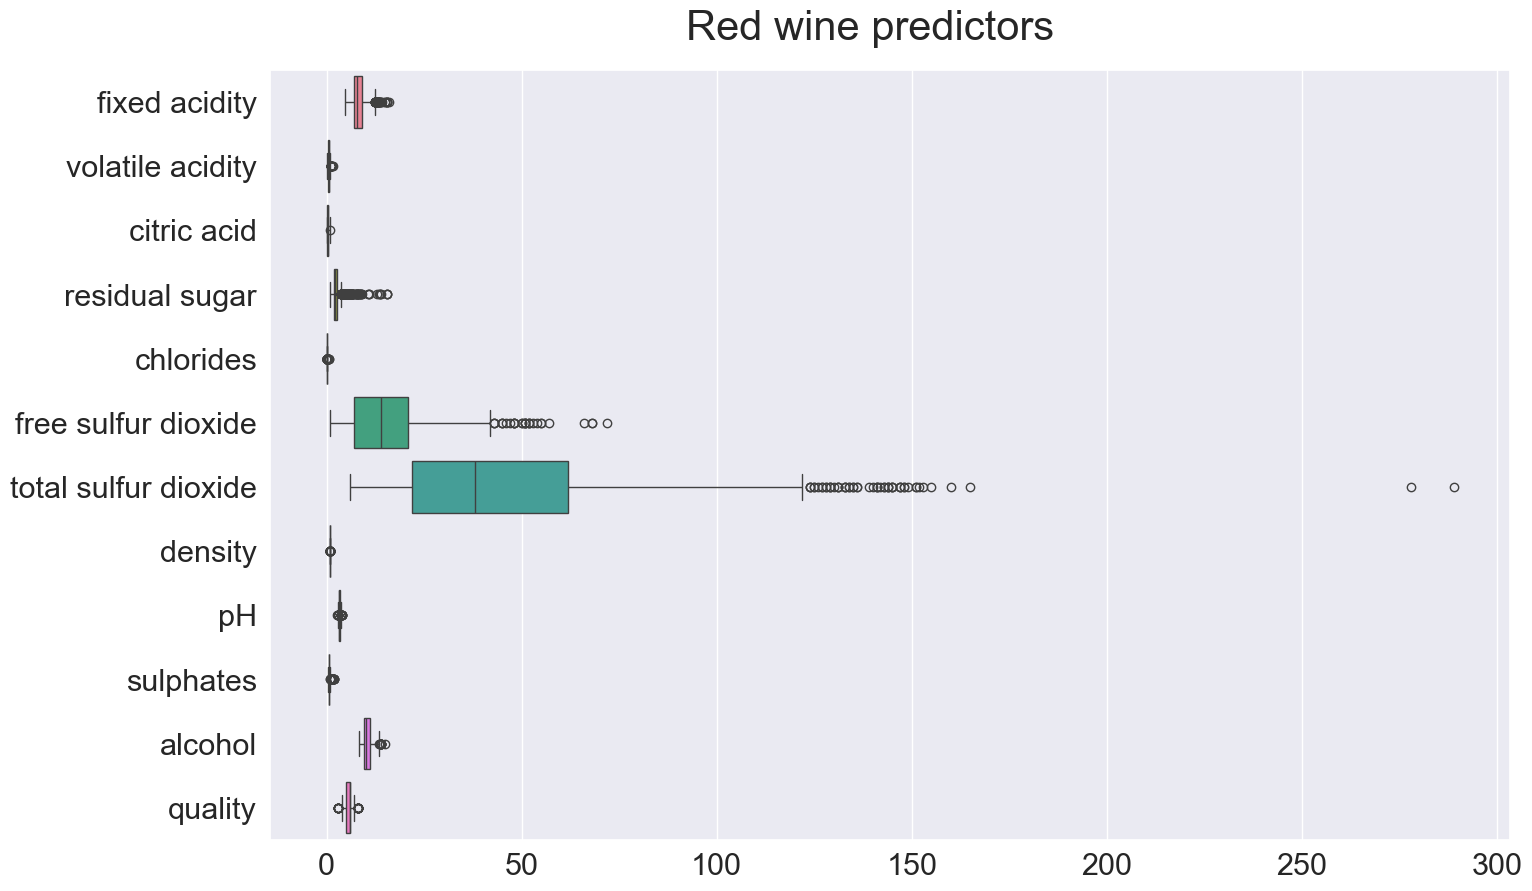

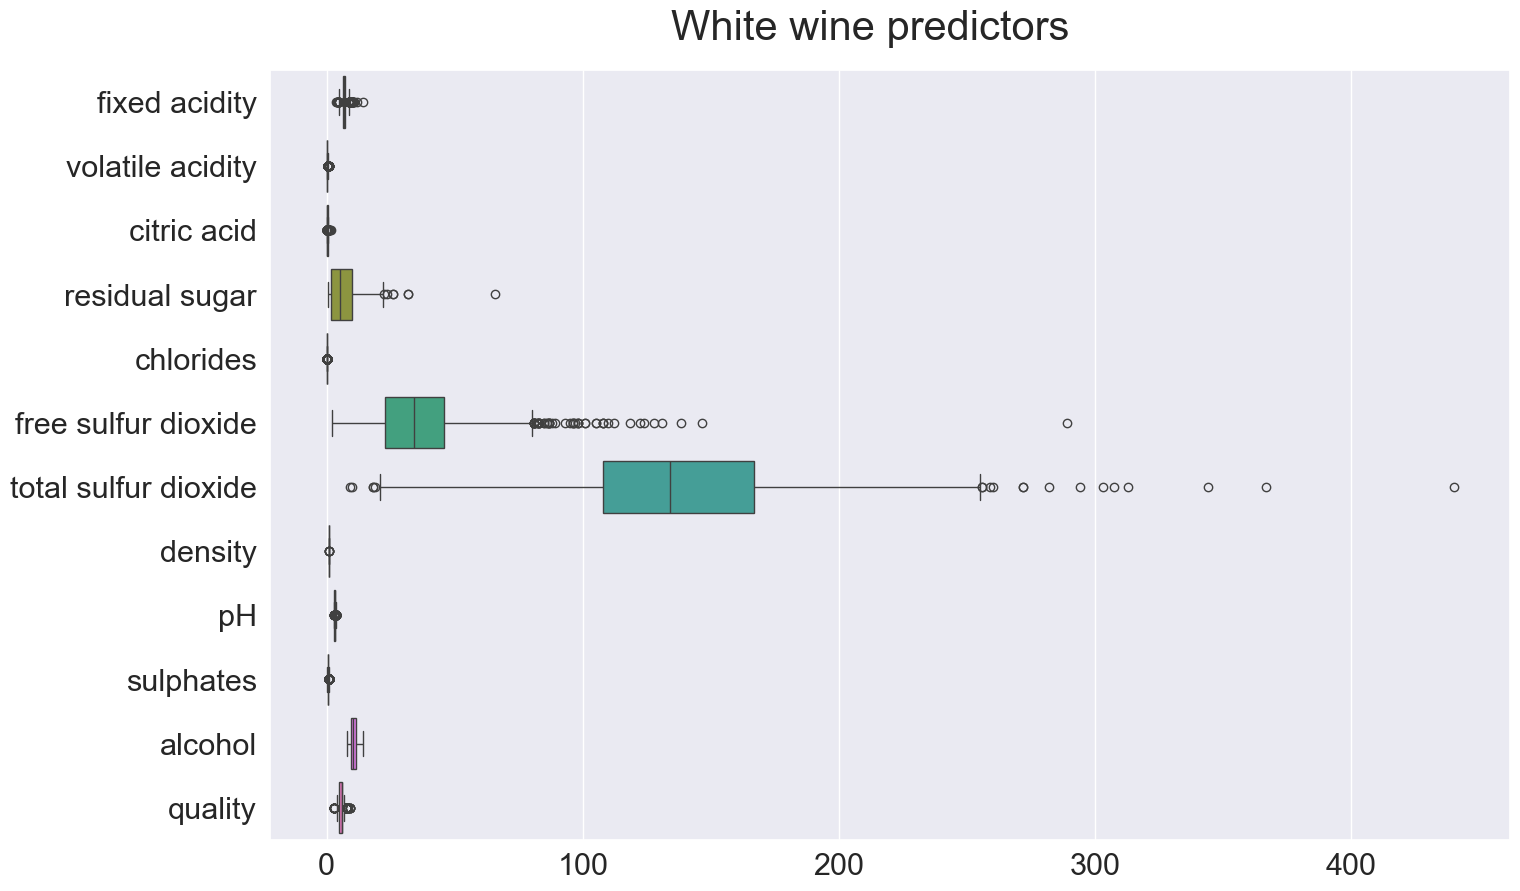

In [31]:
def box_plot(data, height = 10, width = 16, title = "Boxplot"):
    plt.figure(figsize=(width, height))
    plt.suptitle(title, y = 0.94, fontsize = 30)
    sns.set(font_scale = 2)
    sns.boxplot(data = data, orient = "h")
    
box_plot(data = wine_red_df, title = "Red wine predictors")


box_plot(data = wine_white_df, title = "White wine predictors")



Number of outlier data points for red wine: 175 (10.94% of total dataset)
Number of outlier data points for white wine: 56 (1.14% of total dataset)


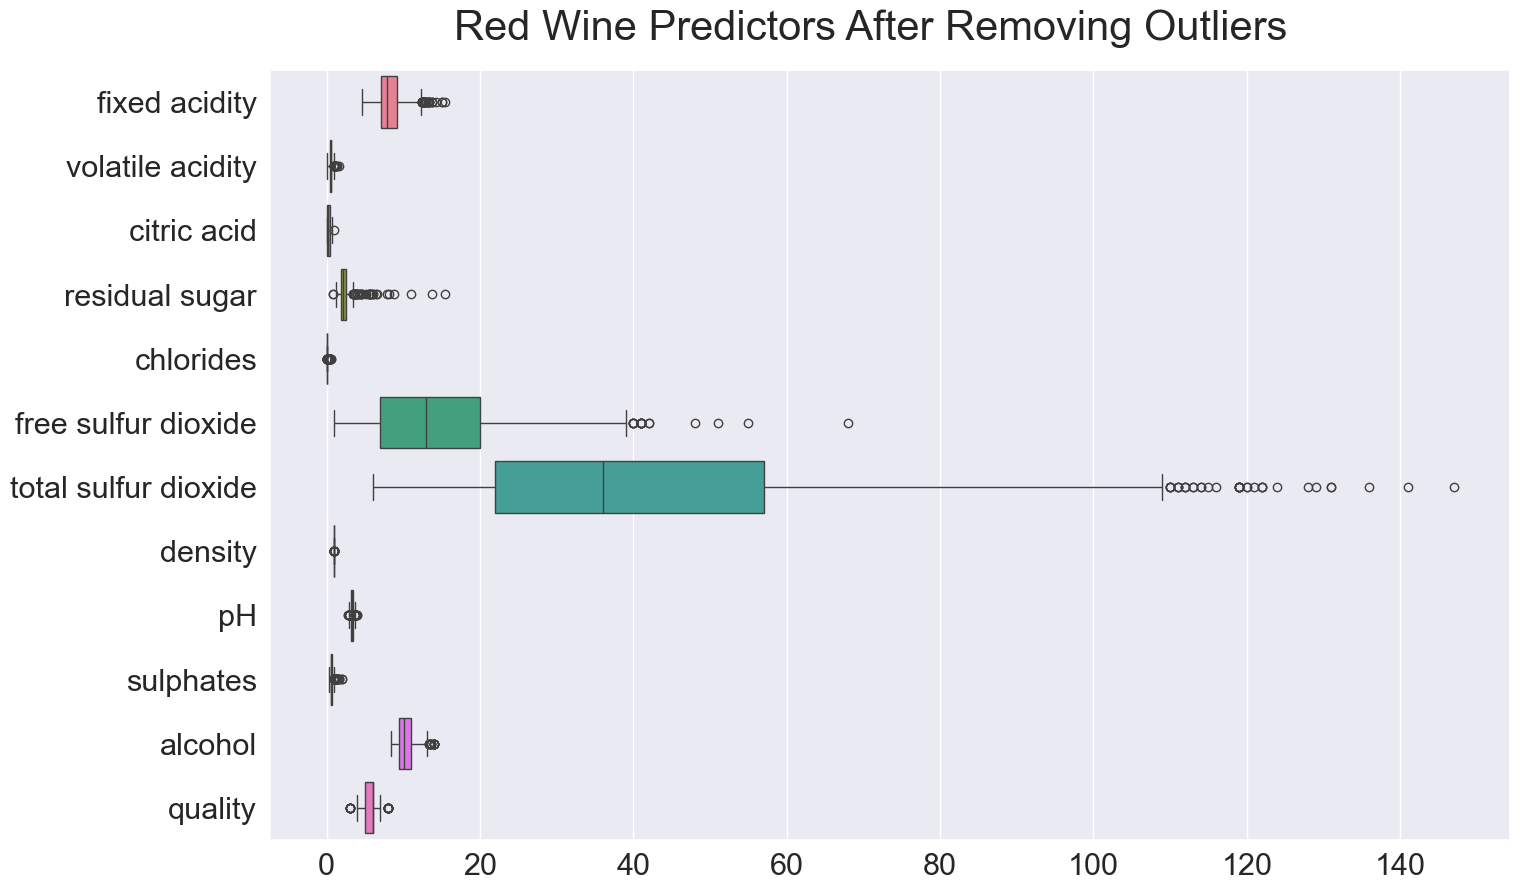

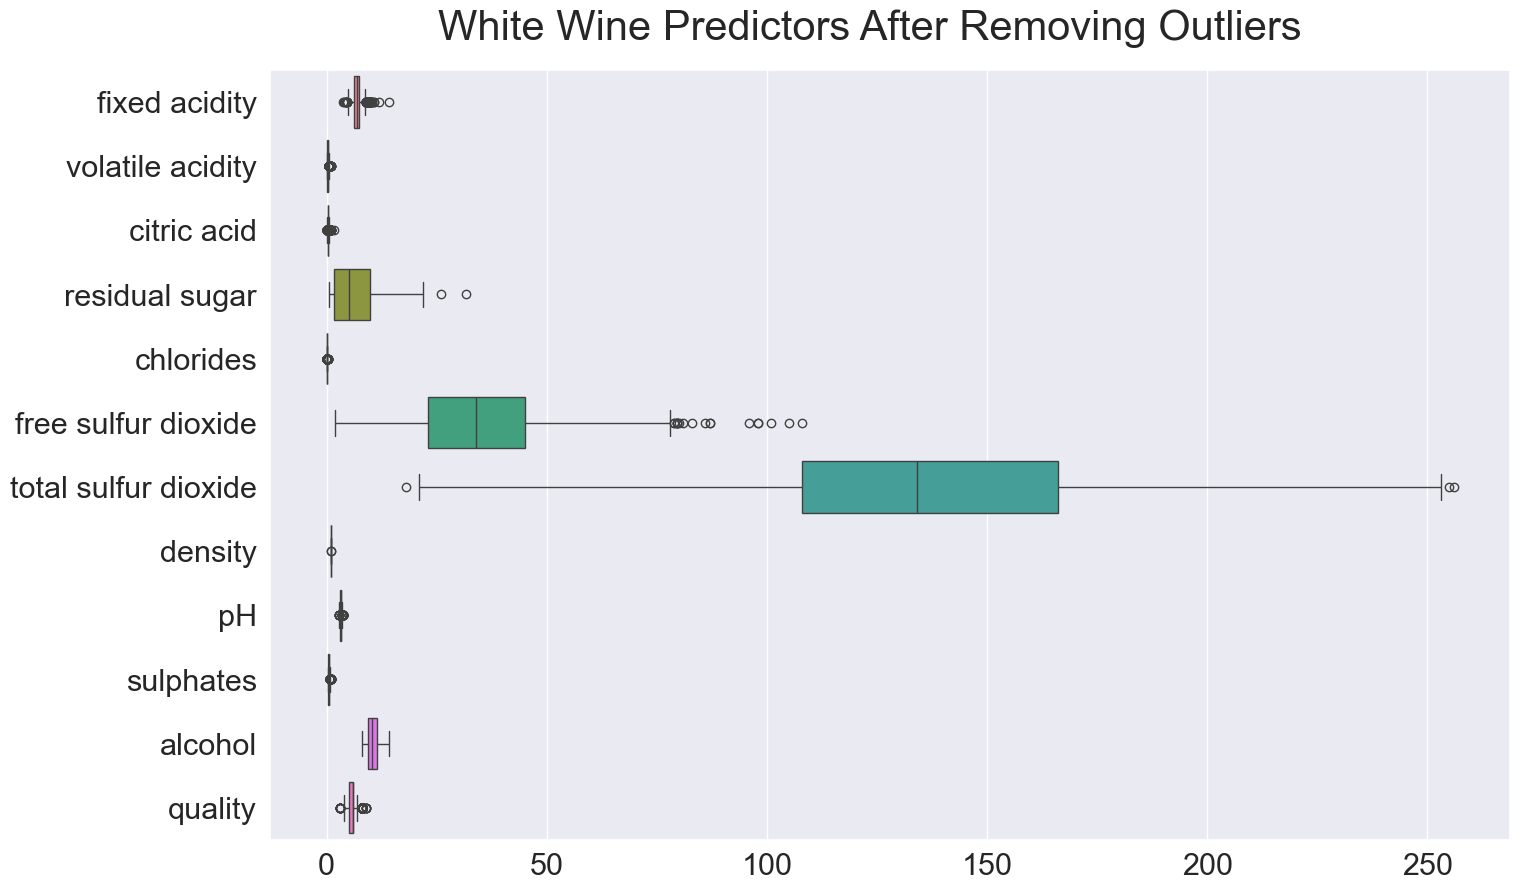

In [32]:

def remove_outliers(data, features_with_outliers):
    """
    Removes outliers from the data based on the given features using the IQR method.
    
    Parameters:
    - data (pd.DataFrame): The input DataFrame.
    - features_with_outliers (list): List of feature names to check for outliers.
    
    Returns:
    - outliers_data (pd.DataFrame): DataFrame containing all outlier rows.
    - data_clean (pd.DataFrame): DataFrame with outliers removed.
    """
    # Create a copy of the data to avoid modifying the original DataFrame
    data_clean = data.copy()
    # Initialize an empty DataFrame to collect outliers
    outliers_list = []
    
    # For each feature, calculate the outlier bounds and collect outliers
    for feature in features_with_outliers:
        # Calculate Q1 and Q3 for the feature
        Q1 = data_clean[feature].quantile(0.25)
        Q3 = data_clean[feature].quantile(0.75)
        IQR = Q3 - Q1
        # Compute the bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data_clean[(data_clean[feature] < lower_bound) | (data_clean[feature] > upper_bound)]
        # Append outliers to the list
        outliers_list.append(outliers)
    
    # Concatenate all outliers and drop duplicates
    outliers_data = pd.concat(outliers_list).drop_duplicates()
    # Remove outliers from the data
    data_clean = data_clean.drop(outliers_data.index)
    # Reset index for the cleaned data
    data_clean.reset_index(drop=True, inplace=True)
    
    return outliers_data, data_clean

# List of features with significant outliers
features_with_outliers = ['free sulfur dioxide', 'total sulfur dioxide', 'residual sugar']

# Remove outliers from red wine data
wine_red_outliers_data, wine_red_df_cleared = remove_outliers(wine_red_df, features_with_outliers)

# Remove outliers from white wine data
wine_white_outliers_data, wine_white_df_cleared = remove_outliers(wine_white_df, features_with_outliers)

# Print the number of outliers removed
print(f"Number of outlier data points for red wine: {wine_red_outliers_data.shape[0]} "
      f"({(wine_red_outliers_data.shape[0] / wine_red_df.shape[0] * 100):.2f}% of total dataset)")

print(f"Number of outlier data points for white wine: {wine_white_outliers_data.shape[0]} "
      f"({(wine_white_outliers_data.shape[0] / wine_white_df.shape[0] * 100):.2f}% of total dataset)")

# Plot box plots to observe the reduction in outliers
box_plot(data=wine_red_df_cleared, title="Red Wine Predictors After Removing Outliers")
box_plot(data=wine_white_df_cleared, title="White Wine Predictors After Removing Outliers")

# Observations

## 1. Red Wine

a. Citric acid and fixed acidity +ve coorelation= **+0.67**  
b. Density and fixed acidity +ve coorelation= **+0.67**  
c. pH and fixed acidity -ve coorelation= **-0.67**  

## 2. White Wine

a. Density and Residual Sugar +ve coorelation= **+0.84**  
b. Density and alcohol -ve coorelation= **-.78**  

In [33]:
scaler = preprocessing.MinMaxScaler()

wine_red_df_preprocessed = pd.DataFrame(scaler.fit_transform(wine_red_df.iloc[:,:-1]))
wine_white_df_preprocessed = pd.DataFrame(scaler.fit_transform(wine_white_df_cleared.iloc[:,:-1]))

wine_red_df_preprocessed.columns = wine_red_df.columns[:-1]
wine_white_df_preprocessed.columns = wine_white_df.columns[:-1]

In [34]:

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(wine_red_df_preprocessed, wine_red_df.iloc[:, -1],
                                                    test_size=0.20, random_state=1)
X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(wine_white_df_preprocessed, wine_white_df_cleared.iloc[:, -1],
                                                    test_size=0.20, random_state=1)

In [35]:
# applying linear regression on red wine data
linear_model = LinearRegression()
linear_model.fit(X_train_red, y_train_red)
y_pred_red = linear_model.predict(X_test_red)


# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_red, y_pred_red)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_red, y_pred_red)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_red, y_pred_red)


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f} ")

print("Accuracy score ",accuracy_score(y_test_red,np.round(y_pred_red,0)))

print("Classification Report of RED WINE data")
report = classification_report(y_test_red, np.round(y_pred_red,0))
print(report)

Mean Absolute Error (MAE): 0.47
Mean Squared Error (MSE): 0.38
Root Mean Squared Error (RMSE): 0.62
R2 Score: 0.33 
Accuracy score  0.634375
Classification Report of RED WINE data
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        13
           5       0.70      0.73      0.71       140
           6       0.59      0.70      0.64       134
           7       0.47      0.23      0.31        30
           8       0.00      0.00      0.00         2

    accuracy                           0.63       320
   macro avg       0.29      0.28      0.28       320
weighted avg       0.60      0.63      0.61       320



In [36]:
# applying linear regression on red wine data
linear_model = LinearRegression()
linear_model.fit(X_train_white, y_train_white)
y_pred_white = linear_model.predict(X_test_white)


# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_white, y_pred_white)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_white, y_pred_white)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_white, y_pred_white)


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f} ")

print("Accuracy score ",accuracy_score(y_test_white,np.round(y_pred_white,0)))

print("Classification Report of White WINE data")
report = classification_report(y_test_white, np.round(y_pred_white,0))
print(report)

Mean Absolute Error (MAE): 0.58
Mean Squared Error (MSE): 0.54
Root Mean Squared Error (RMSE): 0.74
R2 Score: 0.31 
Accuracy score  0.4953560371517028
Classification Report of White WINE data
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        47
           5       0.55      0.37      0.44       281
           6       0.49      0.78      0.60       430
           7       0.43      0.23      0.30       180
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00         1

    accuracy                           0.50       969
   macro avg       0.21      0.20      0.19       969
weighted avg       0.46      0.50      0.45       969



In [37]:

model = OrdinalRidge()
model.fit(X_train_red, y_train_red)

# Predict on the test set
y_pred_red = model.predict(X_test_red)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_red, y_pred_red)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_red, y_pred_red)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_red, y_pred_red)


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f} ")


print("Accuracy score ",accuracy_score(y_test_red,y_pred_red))

print("Classification Report of RED WINE data")
report = classification_report(y_test_red, y_pred_red)
print(report)

Mean Absolute Error (MAE): 0.39
Mean Squared Error (MSE): 0.44
Root Mean Squared Error (RMSE): 0.67
R2 Score: 0.22 
Accuracy score  0.640625
Classification Report of RED WINE data
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        13
           5       0.70      0.73      0.71       140
           6       0.60      0.72      0.65       134
           7       0.54      0.23      0.33        30
           8       0.00      0.00      0.00         2

    accuracy                           0.64       320
   macro avg       0.31      0.28      0.28       320
weighted avg       0.61      0.64      0.62       320



In [39]:

model = OrdinalRidge()
model.fit(X_train_white, y_train_white)

# Predict on the test set
y_pred_white = model.predict(X_test_white)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_white, y_pred_white)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test_white, y_pred_white)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_white, y_pred_white)


print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f} ")


print("Accuracy score ",accuracy_score(y_test_white,y_pred_white))

print("Classification Report of White WINE data")
report = classification_report(y_test_white, y_pred_white)
print(report)

Mean Absolute Error (MAE): 0.55
Mean Squared Error (MSE): 0.66
Root Mean Squared Error (RMSE): 0.81
R2 Score: 0.17 
Accuracy score  0.5015479876160991
Classification Report of White WINE data
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        47
           5       0.57      0.37      0.45       281
           6       0.49      0.80      0.61       430
           7       0.43      0.21      0.28       180
           8       0.00      0.00      0.00        29
           9       0.00      0.00      0.00         1

    accuracy                           0.50       969
   macro avg       0.21      0.20      0.19       969
weighted avg       0.46      0.50      0.45       969



In [40]:
mod_prob = OrderedModel(wine_red_df.iloc[:,-1],wine_red_df_preprocessed,distr='logit')

res_prob = mod_prob.fit(method='bfgs')
res_prob.summary()



Optimization terminated successfully.
         Current function value: 0.961466
         Iterations: 111
         Function evaluations: 114
         Gradient evaluations: 114


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                quality   Log-Likelihood:                -1537.4
Model:                   OrderedModel   AIC:                             3107.
Method:            Maximum Likelihood   BIC:                             3193.
Date:                Sun, 27 Oct 2024                                         
Time:                        13:09:59                                         
No. Observations:                1599                                         
Df Residuals:                    1583                                         
Df Model:                          11                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fixed acidity            1.4513      0.930      1.560      0.119      -0.372       3.275
volatile acidity        -4.9560      0.588     -8.422      0.000      -6.109      -3.803
citric acid             -0.8024      0.462     -1.736      0.083      -1.708       0.104
residual sugar           1.2814      0.700      1.830      0.067      -0.091       2.654
chlorides               -3.0747      0.814     -3.776      0.000      -4.671      -1.479
free sulfur dioxide      0.9745      0.483      2.017      0.044       0.027       1.922
total sulfur dioxide    -3.1528      0.670     -4.703      0.000      -4.467      -1.839
density                 -1.0452      0.931     -1.122      0.262      -2.870       0.780
pH                      -1.0792      0.763     -1.414      0.157      -2.575       0.417
sulphates                4.8470      0.614      7.898      0.000       3.644       6.050
alcohol                  5.3994      0.554      9.746      0.000       4.314       6.485
3/4                     -5.9125      0.577    -10.240      0.000      -7.044      -4.781
4/5                      0.6512      0.154      4.238      0.000       0.350       0.952
5/6                      1.3120      0.039     33.482      0.000       1.235       1.389
6/7                      1.0502      0.038     27.808      0.000       0.976       1.124
7/8                      1.1016      0.080     13.846      0.000       0.946       1.258
========================================================================================
"""

In [41]:

mod_log = OrderedModel(wine_white_df_cleared.iloc[:,-1],wine_white_df_preprocessed,distr='logit')

res_log = mod_log.fit(method='bfgs')
res_log.summary()



Optimization terminated successfully.
         Current function value: 1.102461
         Iterations: 134
         Function evaluations: 138
         Gradient evaluations: 138


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                quality   Log-Likelihood:                -5338.1
Model:                   OrderedModel   AIC:                         1.071e+04
Method:            Maximum Likelihood   BIC:                         1.082e+04
Date:                Sun, 27 Oct 2024                                         
Time:                        13:10:08                                         
No. Observations:                4842                                         
Df Residuals:                    4825                                         
Df Model:                          11                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fixed acidity            3.1261      0.635      4.926      0.000       1.882       4.370
volatile acidity        -5.0296      0.317    -15.866      0.000      -5.651      -4.408
citric acid              0.1504      0.409      0.368      0.713      -0.651       0.951
residual sugar           7.8880      0.721     10.945      0.000       6.475       9.300
chlorides               -0.1546      0.472     -0.328      0.743      -1.079       0.770
free sulfur dioxide      1.6324      0.253      6.444      0.000       1.136       2.129
total sulfur dioxide    -0.1077      0.241     -0.447      0.655      -0.580       0.365
density                -12.6514      1.453     -8.707      0.000     -15.499      -9.804
pH                       2.6044      0.326      7.978      0.000       1.965       3.244
sulphates                1.5927      0.227      7.029      0.000       1.149       2.037
alcohol                  2.1404      0.480      4.459      0.000       1.200       3.081
3/4                     -6.0950      0.415    -14.690      0.000      -6.908      -5.282
4/5                      0.9864      0.098     10.107      0.000       0.795       1.178
5/6                      1.1259      0.027     41.195      0.000       1.072       1.179
6/7                      0.9589      0.020     48.684      0.000       0.920       0.998
7/8                      0.8193      0.034     24.125      0.000       0.753       0.886
8/9                      1.2983      0.121     10.757      0.000       1.062       1.535
========================================================================================
"""